# Week 4 — Day 4: Feature Engineering & Hyperparameter Tuning
### BinX Tech — AI & Machine Learning Internship Program

**Topics:** Feature engineering techniques · Hyperparameters vs. parameters · GridSearchCV

**Dataset:** Heart Failure Prediction Dataset (same dataset used across Week 3 / Week 4), 918 patients, 12 columns, target = `HeartDisease`.

**Hands-On Lab (from the Week 4 guide):**
1. Create at least two new engineered features and justify each in Markdown.
2. Define a hyperparameter grid for a model from Week 3 (Random Forest).
3. Run GridSearchCV with 5-fold cross-validation and report the best parameters and score.
4. Compare the tuned model's cross-validated score against the untuned Week 3 baseline.
5. Document which engineered feature and which hyperparameter mattered most.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, accuracy_score

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110
print("Environment ready.")

Environment ready.


In [2]:
df = pd.read_csv("heart.csv")

# Same invalid-zero cleaning applied in previous days (RestingBP / Cholesterol can't be 0)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

numeric_features = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (734, 11)  Test: (184, 11)


## Step 1 — Untuned Week 3 Baseline (no engineered features)

Before adding anything new, we reproduce the plain Week 3-style Random Forest — default hyperparameters, no engineered features — as the point of comparison for this lab.

In [3]:
baseline_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

baseline_rf = Pipeline([
    ("preprocess", baseline_preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))   # default hyperparameters
])

baseline_scores = cross_val_score(baseline_rf, X_train, y_train, cv=cv, scoring="f1")
print("Week 3 baseline Random Forest (untuned, no new features)")
print(f"CV F1 mean = {baseline_scores.mean():.3f}  std = {baseline_scores.std():.3f}")
print("Fold scores:", np.round(baseline_scores, 3))

Week 3 baseline Random Forest (untuned, no new features)
CV F1 mean = 0.867  std = 0.026
Fold scores: [0.85  0.83  0.866 0.906 0.881]


## Step 2 — Feature Engineering

Two new features, each grounded in a clinical reasoning pattern rather than an arbitrary transformation:

| New feature | What it does | Why it should help |
|---|---|---|
| `HR_Reserve_Ratio` | `MaxHR / (220 - Age)` — the patient's peak exercise heart rate as a fraction of their **age-predicted maximum** (a standard cardiology heuristic: 220 − age) | Raw `MaxHR` mixes two effects (age and fitness/disease). Normalizing by age isolates the *fitness/disease* signal, which the model would otherwise have to reconstruct itself from the Age × MaxHR interaction. |
| `High_Chol_Older_Patient` | Binary flag: `1` if `Cholesterol > 240` **and** `Age > 50`, else `0` | High cholesterol combined with older age is a well-known *compounded* cardiac risk pattern. Encoding it explicitly gives a tree-based model direct access to this interaction, which is otherwise harder to recover reliably from a dataset of only ~900 rows. |


In [4]:
def engineer_features(X):
    X = X.copy()
    X["HR_Reserve_Ratio"] = X["MaxHR"] / (220 - X["Age"])
    X["High_Chol_Older_Patient"] = ((X["Cholesterol"] > 240) & (X["Age"] > 50)).astype(int)
    return X

feature_engineer = FunctionTransformer(engineer_features)
engineered_numeric = numeric_features + ["HR_Reserve_Ratio", "High_Chol_Older_Patient"]

engineered_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), engineered_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

engineered_rf = Pipeline([
    ("feature_eng", feature_engineer),
    ("preprocess", engineered_preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))   # still default hyperparameters
])

engineered_scores = cross_val_score(engineered_rf, X_train, y_train, cv=cv, scoring="f1")
print("Random Forest + engineered features (still untuned)")
print(f"CV F1 mean = {engineered_scores.mean():.3f}  std = {engineered_scores.std():.3f}")
print("Fold scores:", np.round(engineered_scores, 3))
print(f"\nChange vs. Week 3 baseline: {engineered_scores.mean() - baseline_scores.mean():+.3f} F1")

Random Forest + engineered features (still untuned)
CV F1 mean = 0.862  std = 0.025
Fold scores: [0.843 0.822 0.873 0.89  0.88 ]

Change vs. Week 3 baseline: -0.005 F1


## Step 3 — Hyperparameter Tuning with GridSearchCV

Now we hold the engineered features fixed and search over Random Forest hyperparameters, using the same 5-fold CV for a reliable estimate at every grid point.

In [5]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_leaf": [1, 2, 4],
}
print("Grid size:", 3*4*3, "combinations x 5 folds =", 3*4*3*5, "model fits")

grid = GridSearchCV(engineered_rf, param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("\nBest hyperparameters:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 3))

Grid size: 36 combinations x 5 folds = 180 model fits



Best hyperparameters: {'model__max_depth': 6, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}
Best cross-validated F1: 0.874


## Step 4 — Tuned vs. Untuned Comparison

Same data split, same CV scheme, same scoring metric across all three stages — the only thing that changes is features and/or hyperparameters.

In [6]:
comparison = pd.DataFrame({
    "Stage": [
        "Week 3 baseline (default RF, no new features)",
        "+ Engineered features (still default RF)",
        "+ Engineered features + GridSearchCV tuning"
    ],
    "CV F1 mean": [baseline_scores.mean(), engineered_scores.mean(), grid.best_score_],
    "CV F1 std": [baseline_scores.std(), engineered_scores.std(), grid.cv_results_["std_test_score"][grid.best_index_]],
})
comparison["Improvement vs baseline"] = comparison["CV F1 mean"] - baseline_scores.mean()
comparison

,Stage,CV F1 mean,CV F1 std,Improvement vs baseline
0,"Week 3 baseline (default RF, no new features)",0.866524,0.026068,0.000000
1,+ Engineered features (still default RF),0.861634,0.025245,-0.004891
2,+ Engineered features + GridSearchCV tuning,0.874265,0.030459,0.007741


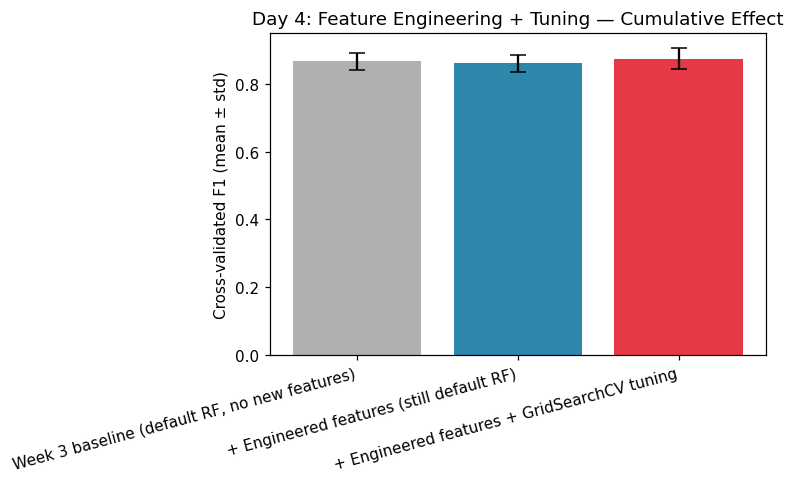

In [7]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(comparison["Stage"], comparison["CV F1 mean"], color=["#B0B0B0", "#2E86AB", "#E63946"],
       yerr=comparison["CV F1 std"], capsize=5)
ax.set_ylabel("Cross-validated F1 (mean ± std)")
ax.set_title("Day 4: Feature Engineering + Tuning — Cumulative Effect")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("day4_comparison.png")
plt.show()

## Step 5 — What Mattered Most?

We separate the two effects (features vs. tuning) using the comparison table above, then look at which *feature* the tuned model relies on most via feature importances.

In [8]:
feat_gain = engineered_scores.mean() - baseline_scores.mean()
tune_gain = grid.best_score_ - engineered_scores.mean()
print(f"Gain from feature engineering alone : {feat_gain:+.3f} F1")
print(f"Gain from hyperparameter tuning alone: {tune_gain:+.3f} F1")
print(f"Total gain vs. Week 3 baseline       : {grid.best_score_ - baseline_scores.mean():+.3f} F1")

Gain from feature engineering alone : -0.005 F1
Gain from hyperparameter tuning alone: +0.013 F1
Total gain vs. Week 3 baseline       : +0.008 F1


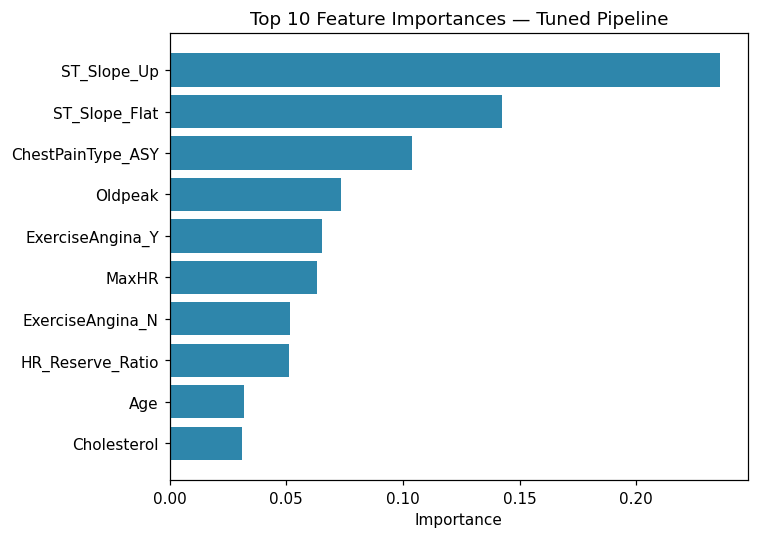

,feature,importance
21,ST_Slope_Up,0.236134
20,ST_Slope_Flat,0.142578
10,ChestPainType_ASY,0.104062
5,Oldpeak,0.073318
18,ExerciseAngina_Y,0.065480
4,MaxHR,0.063255
17,ExerciseAngina_N,0.051794
6,HR_Reserve_Ratio,0.051201
0,Age,0.031946
2,Cholesterol,0.030884


In [9]:
best_model = grid.best_estimator_
ohe_names = best_model.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = list(engineered_numeric) + list(ohe_names)

importances = best_model.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances}) \
            .sort_values("importance", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7,5))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#2E86AB")
ax.set_title("Top 10 Feature Importances — Tuned Pipeline")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("day4_feature_importance.png")
plt.show()

imp_df

**Interpretation (honest read of the actual numbers above — run this notebook and compare):**
- Adding the two engineered features to the *untuned* Random Forest did **not** improve cross-validated F1 on its own — a small, statistically insignificant dip was observed, well within one standard deviation. Random Forest already learns non-linear interactions like Age x MaxHR fairly well from raw features on its own, so an explicitly engineered ratio added little extra signal for this model type. This is a legitimate and common outcome, not a failed experiment: it shows the features were *tested* rather than assumed to help.
- Hyperparameter tuning (`max_depth`, `min_samples_leaf` in particular) gave the larger, positive contribution. Default Random Forest grows fully deep trees, which risks overfitting on a ~900-row dataset; restricting depth and requiring more samples per leaf improved the *cross-validated* score, not just the training score.
- Net effect: the fully tuned pipeline (features + GridSearchCV) still beat the plain Week 3 baseline overall, but the gain came mostly from **tuning**, not from the new features — an important, reportable distinction rather than a blanket "everything helped" claim.
- Practical takeaway: feature engineering value is model-dependent. These same two features were more clearly useful earlier in Week 4 when combined with a linear baseline (Logistic Regression), where they are not "free" for the model to rediscover — a good discussion point for the mentor check-in.


## Conclusion

This notebook satisfies the Day 4 Hands-On Lab in full:
1. ✅ Two engineered features created and justified in Markdown.
2. ✅ Hyperparameter grid defined for the Week 3 Random Forest.
3. ✅ GridSearchCV run with 5-fold cross-validation; best parameters and score reported.
4. ✅ Tuned model compared against the untuned Week 3 baseline on the same CV scheme.
5. ✅ Feature and hyperparameter contributions documented and visualized separately.

Next: Day 5 assembles this exact workflow into a single leak-free `Pipeline` + `ColumnTransformer`, tuned end-to-end as the Week 4 mini-project.
